<div class="alert alert-block alert-success">


# 02 — cleaning-transforming pipeline

## Goal of this notebook
### Implement the data cleaning\transforming for better data quality:
#### issues found in previous notebook:
- add a transformed numeric_net_transfer_record column in clubs table to show the pure number without any + ,- ,k or m symbol 
- splitting player_code column in players table to first_name and last_name, which is not the best approach we can do it per-query if needed
- replacing the height_in_cm column in players table lower then 100cm with the median or mean 
- handling the '-1' minute but the best approach is to live it at -1 because 90 percent of the '-1' minute columns are shootout events and replacing them with median or mean will cause biased analysis on shootout events

#### issues to actually implement:
- add a transformed numeric_net_transfer_record column in clubs table to show the pure number without any + ,- ,k or m symbol 
- replacing the height_in_cm column in players table lower then 100cm with the median or mean 

##### the changes are going to take place directly on the database not the raw data

In [2]:
# importing the necessaries
import sys
import os
# Adding the root to the path to use utils folder
sys.path.append(os.path.abspath(os.path.join('..')))

from utils.db_utils import run_query , execute_ddl
from utils.custom_plots import distribution_plot, outlier_plot


import plotly.io as pio
pio.renderers.default = "png"  # drop these 2 lines if you want interactive charts locally

<div class="alert alert-block alert-success">

# Implementing the first issue:
- add a transformed numeric_net_transfer_record column in clubs table to show the pure number without any + ,- ,k or m symbol 


In [ ]:
# this query adds a computed column which is dependent on the mother column(net_transfer_record) and obeys the changes on the mother column.

first_q = r'''
ALTER TABLE clubs 
ADD COLUMN numeric_net_transfer_record NUMERIC GENERATED ALWAYS AS (
  CASE
    WHEN trim(net_transfer_record) = '+-0' THEN 0
    WHEN trim(net_transfer_record) ILIKE '%m' THEN
      CAST(substring(trim(net_transfer_record), '-?\d+\.?\d*') AS NUMERIC) * 1000000
    WHEN trim(net_transfer_record) ILIKE '%k' THEN
      CAST(substring(trim(net_transfer_record), '-?\d+\.?\d*') AS NUMERIC) * 1000
    ELSE CAST(substring(trim(net_transfer_record), '-?\d+\.?\d*') AS NUMERIC)
  END
) STORED;
'''

execute_ddl(first_q)


✓ Query executed successfully. Rows affected: -1


True

In [6]:
# checking the result:

check_q = '''
select net_transfer_record , numeric_net_transfer_record 
from clubs 
order by random()
limit 20;
'''

check_df = run_query(check_q)
check_df

,net_transfer_record,numeric_net_transfer_record
0,+18.45m,18450000.0
1,-7.94m,-7940000.0
2,+4.72m,4720000.0
3,-3.41m,-3410000.0
4,+6.34m,6340000.0
5,-300k,-300000.0
6,+-0,0.0
7,+-0,0.0
8,+-0,0.0
9,+550k,550000.0


<div class="alert alert-block alert-success">

# Implementing the second issue:
- replacing the height_in_cm column in players table lower then 100cm with the median or mean 


In [7]:
second_q = r'''
update players
set height_in_cm = (
    select PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY height_in_cm)
    from players
    -- excluding the outliers 
    where height_in_cm >= 100
)
where height_in_cm < 100;
'''
execute_ddl(second_q)

# it must affect 2 rows because we had 2 players lower then 100cm

✓ Query executed successfully. Rows affected: 0


True

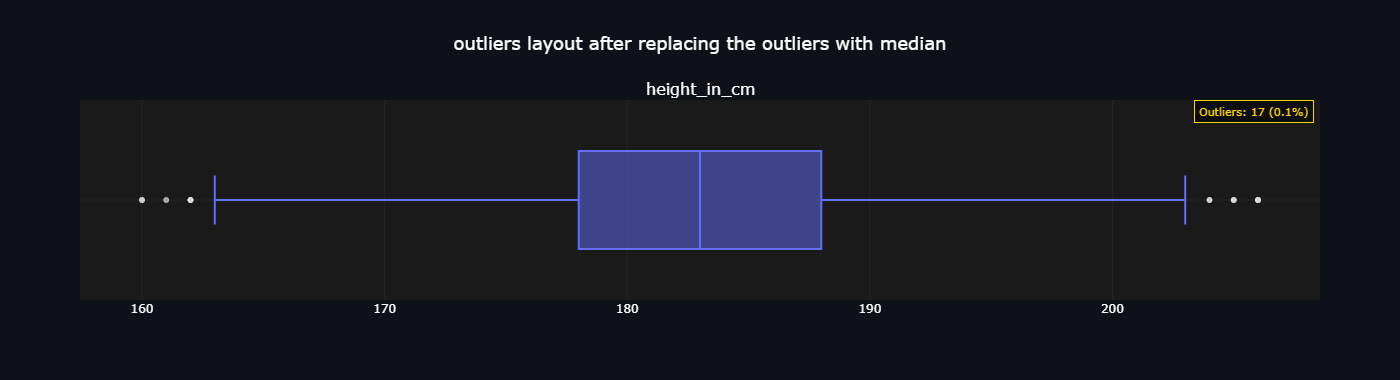

In [8]:
# checking the result:

check_q = '''select height_in_cm from players'''

check_df = run_query(check_q)

box_plot_check = outlier_plot(check_df, n_cols=1, title='outliers layout after replacing the outliers with median')
box_plot_check

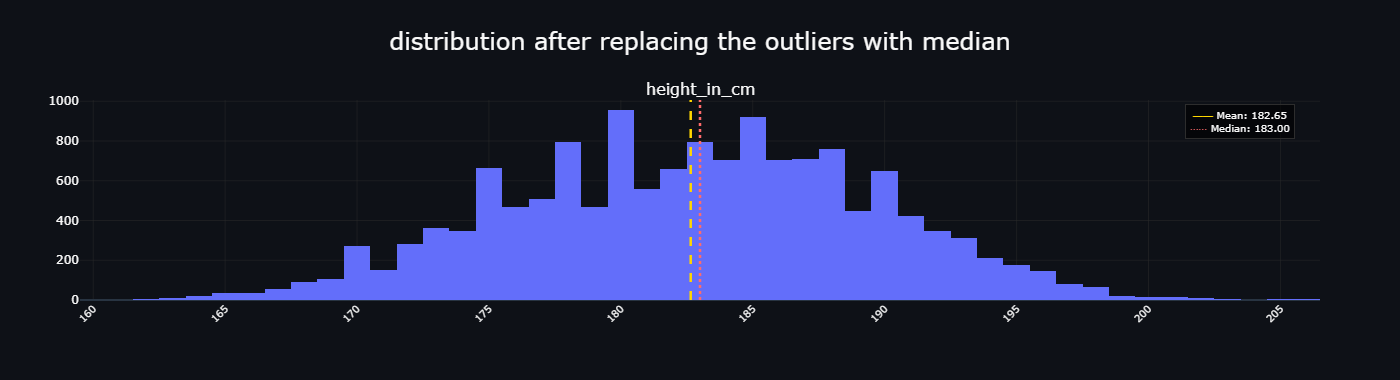

In [9]:
hist_check = distribution_plot(check_df, n_cols=1, title='distribution after replacing the outliers with median')
hist_check

<div class="alert alert-block alert-success">

# Both issues implemented correctly ✔️